# Exploratory Data Analysis (EDA)

## Objective

The objective of this exploratory data analysis is to understand the structure, quality, and main characteristics of the IoT data collected from simulated Moroccan water and electricity networks.

The analysis focuses on identifying data quality issues, studying the distribution of sensor measurements, analyzing failure patterns, and investigating the relationships between operational conditions and equipment failures.

The results of this analysis will guide the data preprocessing, feature engineering, and machine learning modeling phases.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

In [8]:
DB_USER = "postgres"
DB_PASSWORD = "1234"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "onee_predictive_maintenance"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [11]:
df = pd.read_sql(
    "SELECT * FROM iot_measurements;",
    engine
)

print("Data loaded successfully!")

Data loaded successfully!


## Dataset Overview

In [12]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset shape: (201000, 34)
Number of rows: 201000
Number of columns: 34


,measurement_id,timestamp,city,district,sensor_id,network_type,equipment_type,temperature_c,humidity_percent,pressure_bar,...,ambient_temperature,peak_hour,weekend,holiday,season,failure_history_last_30_days,failure_history_last_year,anomaly_score,failure_probability,target_failure
0,1,2022-11-05 19:20:00,Casablanca,District_5,SNR-00386,Water,pumping_station,20.4,77.8,5.25,...,16.9,1,1,0,Autumn,0,2,0.4659,0.2924,0
1,2,2022-03-18 07:40:00,Marrakech,District_2,SNR-00038,Water,pumping_station,20.6,38.1,5.45,...,19.7,1,0,0,Spring,0,1,0.3489,0.0454,0
2,3,2024-06-18 12:50:00,Laayoune,District_3,SNR-01023,Water,pumping_station,37.2,42.9,4.07,...,30.7,0,0,0,Summer,0,3,0.6294,0.4939,1
3,4,2022-03-19 09:40:00,Tangier,District_1,SNR-00204,Water,water_tank,24.7,77.1,3.37,...,16.0,1,1,0,Spring,2,1,0.3702,0.4404,1
4,5,2021-05-14 09:20:00,Dakhla,District_2,SNR-00585,Electricity,substation,41.9,47.2,NaN,...,19.9,1,0,0,Spring,1,2,0.5890,0.1825,0


In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
measurement_id,201000.0,100500.5,1.0,50250.75,100500.5,150750.25,201000.0,58023.846391
timestamp,201000,2022-12-31 10:26:19.161194,2021-01-01 00:00:00,2021-12-29 07:17:30,2022-12-31 09:20:00,2023-12-31 13:10:00,2024-12-31 23:40:00,NaN
temperature_c,198884.0,30.358403,-16.77,23.1,29.9,37.0,720.0,11.777747
humidity_percent,198985.0,57.02929,15.0,46.2,55.7,68.0,99.5,14.55511
pressure_bar,100056.0,3.444658,-1.551,2.68,3.42,4.16,67.05,1.090067
water_flow_l_min,100027.0,251.092522,-125.07,131.3,231.7,344.4,11175.0,166.893079
voltage_v,98962.0,229.943849,-71.4,226.4,229.3,232.2,3505.5,48.113283
current_a,98973.0,134.377145,-68.616,67.71,121.81,185.82,4836.15,92.026202
power_factor,98997.0,0.892591,0.733,0.856,0.892,0.93,0.99,0.047648
frequency_hz,98964.0,49.988865,49.719,49.953,49.991,50.027,50.238,0.055988


In [14]:
df.describe(include="object").T

C:\Users\PC Paradise\AppData\Local\Temp\ipykernel_23668\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
city,201000,10,Tangier,23095
district,201000,5,District_2,42251
sensor_id,201000,1200,SNR-00418,209
network_type,201000,2,Water,101056
equipment_type,201000,7,water_tank,35934
season,201000,4,Spring,50659


In [15]:
df.nunique().sort_values()

network_type                         2
peak_hour                            2
holiday                              2
weekend                              2
target_failure                       2
season                               4
failure_history_last_30_days         5
district                             5
equipment_type                       7
failure_history_last_year           10
city                                10
power_factor                       245
equipment_age_years                277
voltage_v                          421
frequency_hz                       437
ambient_temperature                447
wind_speed                         474
pressure_bar                       581
noise_db                           588
temperature_c                      759
humidity_percent                   811
dust_level                        1001
sensor_id                         1200
maintenance_delay_days            1558
rainfall_mm                       2701
vibration_mm_s           

In [16]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_df = missing_df[
    missing_df["Missing Values"] > 0
].sort_values(
    by="Percentage (%)",
    ascending=False
)

missing_df

,Missing Values,Percentage (%)
energy_consumption_kwh,102060,50.776119
voltage_v,102038,50.765174
frequency_hz,102036,50.764179
current_a,102027,50.759701
power_factor,102003,50.747761
water_flow_l_min,100973,50.235323
pressure_bar,100944,50.220896
temperature_c,2116,1.052736
wind_speed,2060,1.024876
operating_hours,2017,1.003483


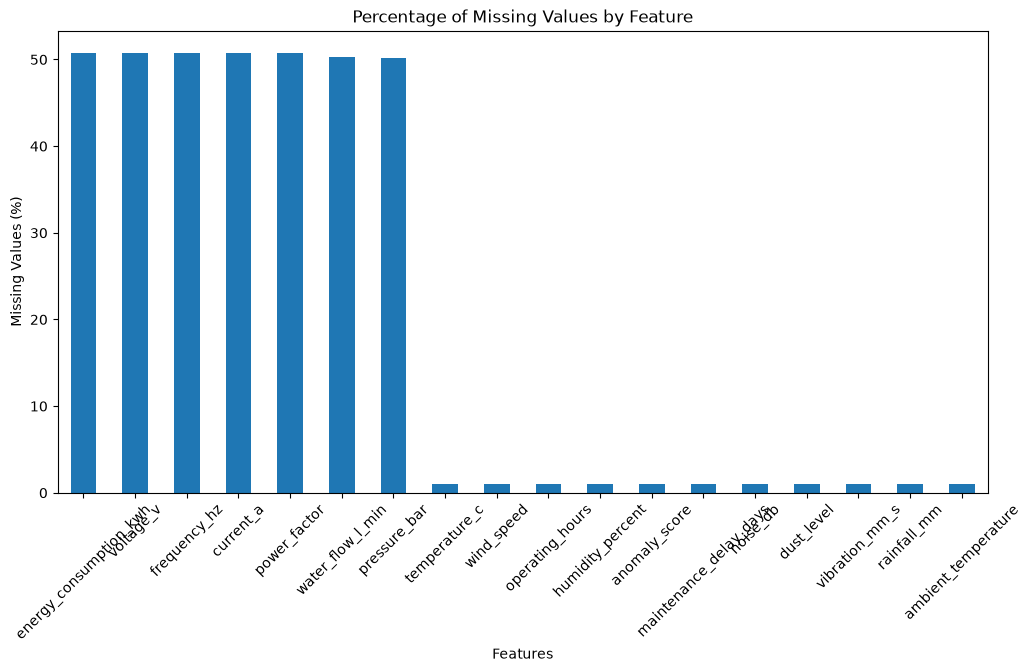

In [17]:
missing_df["Percentage (%)"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Percentage of Missing Values by Feature")
plt.ylabel("Missing Values (%)")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.show()

In [18]:
duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)
print(
    "Percentage of duplicates:",
    round((duplicates / len(df)) * 100, 2),
    "%"
)

Number of duplicated rows: 0
Percentage of duplicates: 0.0 %


In [19]:
failure_counts = df["target_failure"].value_counts()

failure_percentage = (
    df["target_failure"]
    .value_counts(normalize=True)
    * 100
)

print(failure_counts)
print(failure_percentage)

target_failure
0    187287
1     13713
Name: count, dtype: int64
target_failure
0    93.177612
1     6.822388
Name: proportion, dtype: float64


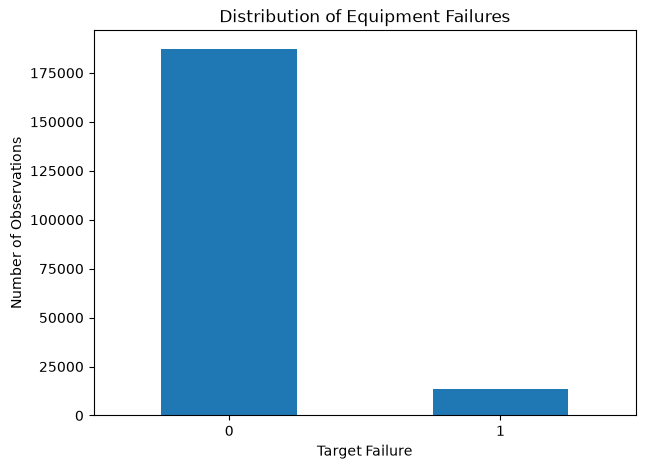

In [20]:
failure_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Equipment Failures")
plt.xlabel("Target Failure")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.show()

## Target Variable Analysis

The target variable is imbalanced, with normal operating observations representing the majority of the dataset and failure events accounting for a relatively small proportion of observations.

This class imbalance reflects a realistic predictive maintenance scenario, where equipment failures are less frequent than normal operating conditions.

Therefore, accuracy alone may not be an appropriate evaluation metric. Precision, recall, F1-score, and ROC-AUC should also be considered during model evaluation.

In [21]:
network_failure = (
    df.groupby("network_type")["target_failure"]
    .agg(["count", "sum", "mean"])
)

network_failure["failure_rate_percent"] = (
    network_failure["mean"] * 100
)

network_failure

,count,sum,mean,failure_rate_percent
network_type,,,,
Electricity,99944,1884,0.018851,1.885056
Water,101056,11829,0.117054,11.705391


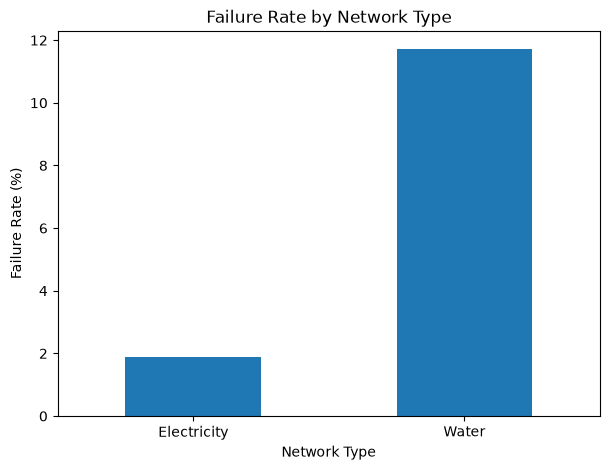

In [22]:
network_failure["failure_rate_percent"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Failure Rate by Network Type")
plt.ylabel("Failure Rate (%)")
plt.xlabel("Network Type")
plt.xticks(rotation=0)
plt.show()

In [23]:
city_failure = (
    df.groupby("city")["target_failure"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

city_failure

city
Laayoune      9.619629
Fès           8.775148
Oujda         8.456800
Casablanca    7.854426
Meknes        6.387969
Rabat         6.317657
Dakhla        6.114263
Marrakech     5.735027
Tangier       5.499026
Agadir        4.184970
Name: target_failure, dtype: float64

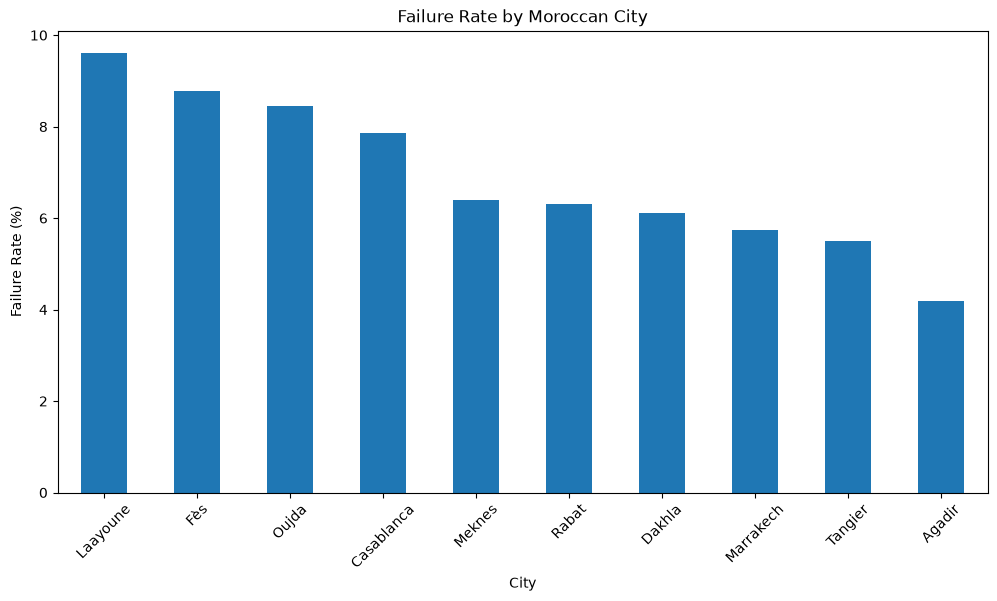

In [24]:
city_failure.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Failure Rate by Moroccan City")
plt.ylabel("Failure Rate (%)")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.show()

In [25]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns)

Index(['measurement_id', 'temperature_c', 'humidity_percent', 'pressure_bar',
       'water_flow_l_min', 'voltage_v', 'current_a', 'power_factor',
       'frequency_hz', 'energy_consumption_kwh', 'vibration_mm_s', 'noise_db',
       'equipment_age_years', 'maintenance_delay_days', 'operating_hours',
       'rainfall_mm', 'wind_speed', 'dust_level', 'ambient_temperature',
       'peak_hour', 'weekend', 'holiday', 'failure_history_last_30_days',
       'failure_history_last_year', 'anomaly_score', 'failure_probability',
       'target_failure'],
      dtype='str')


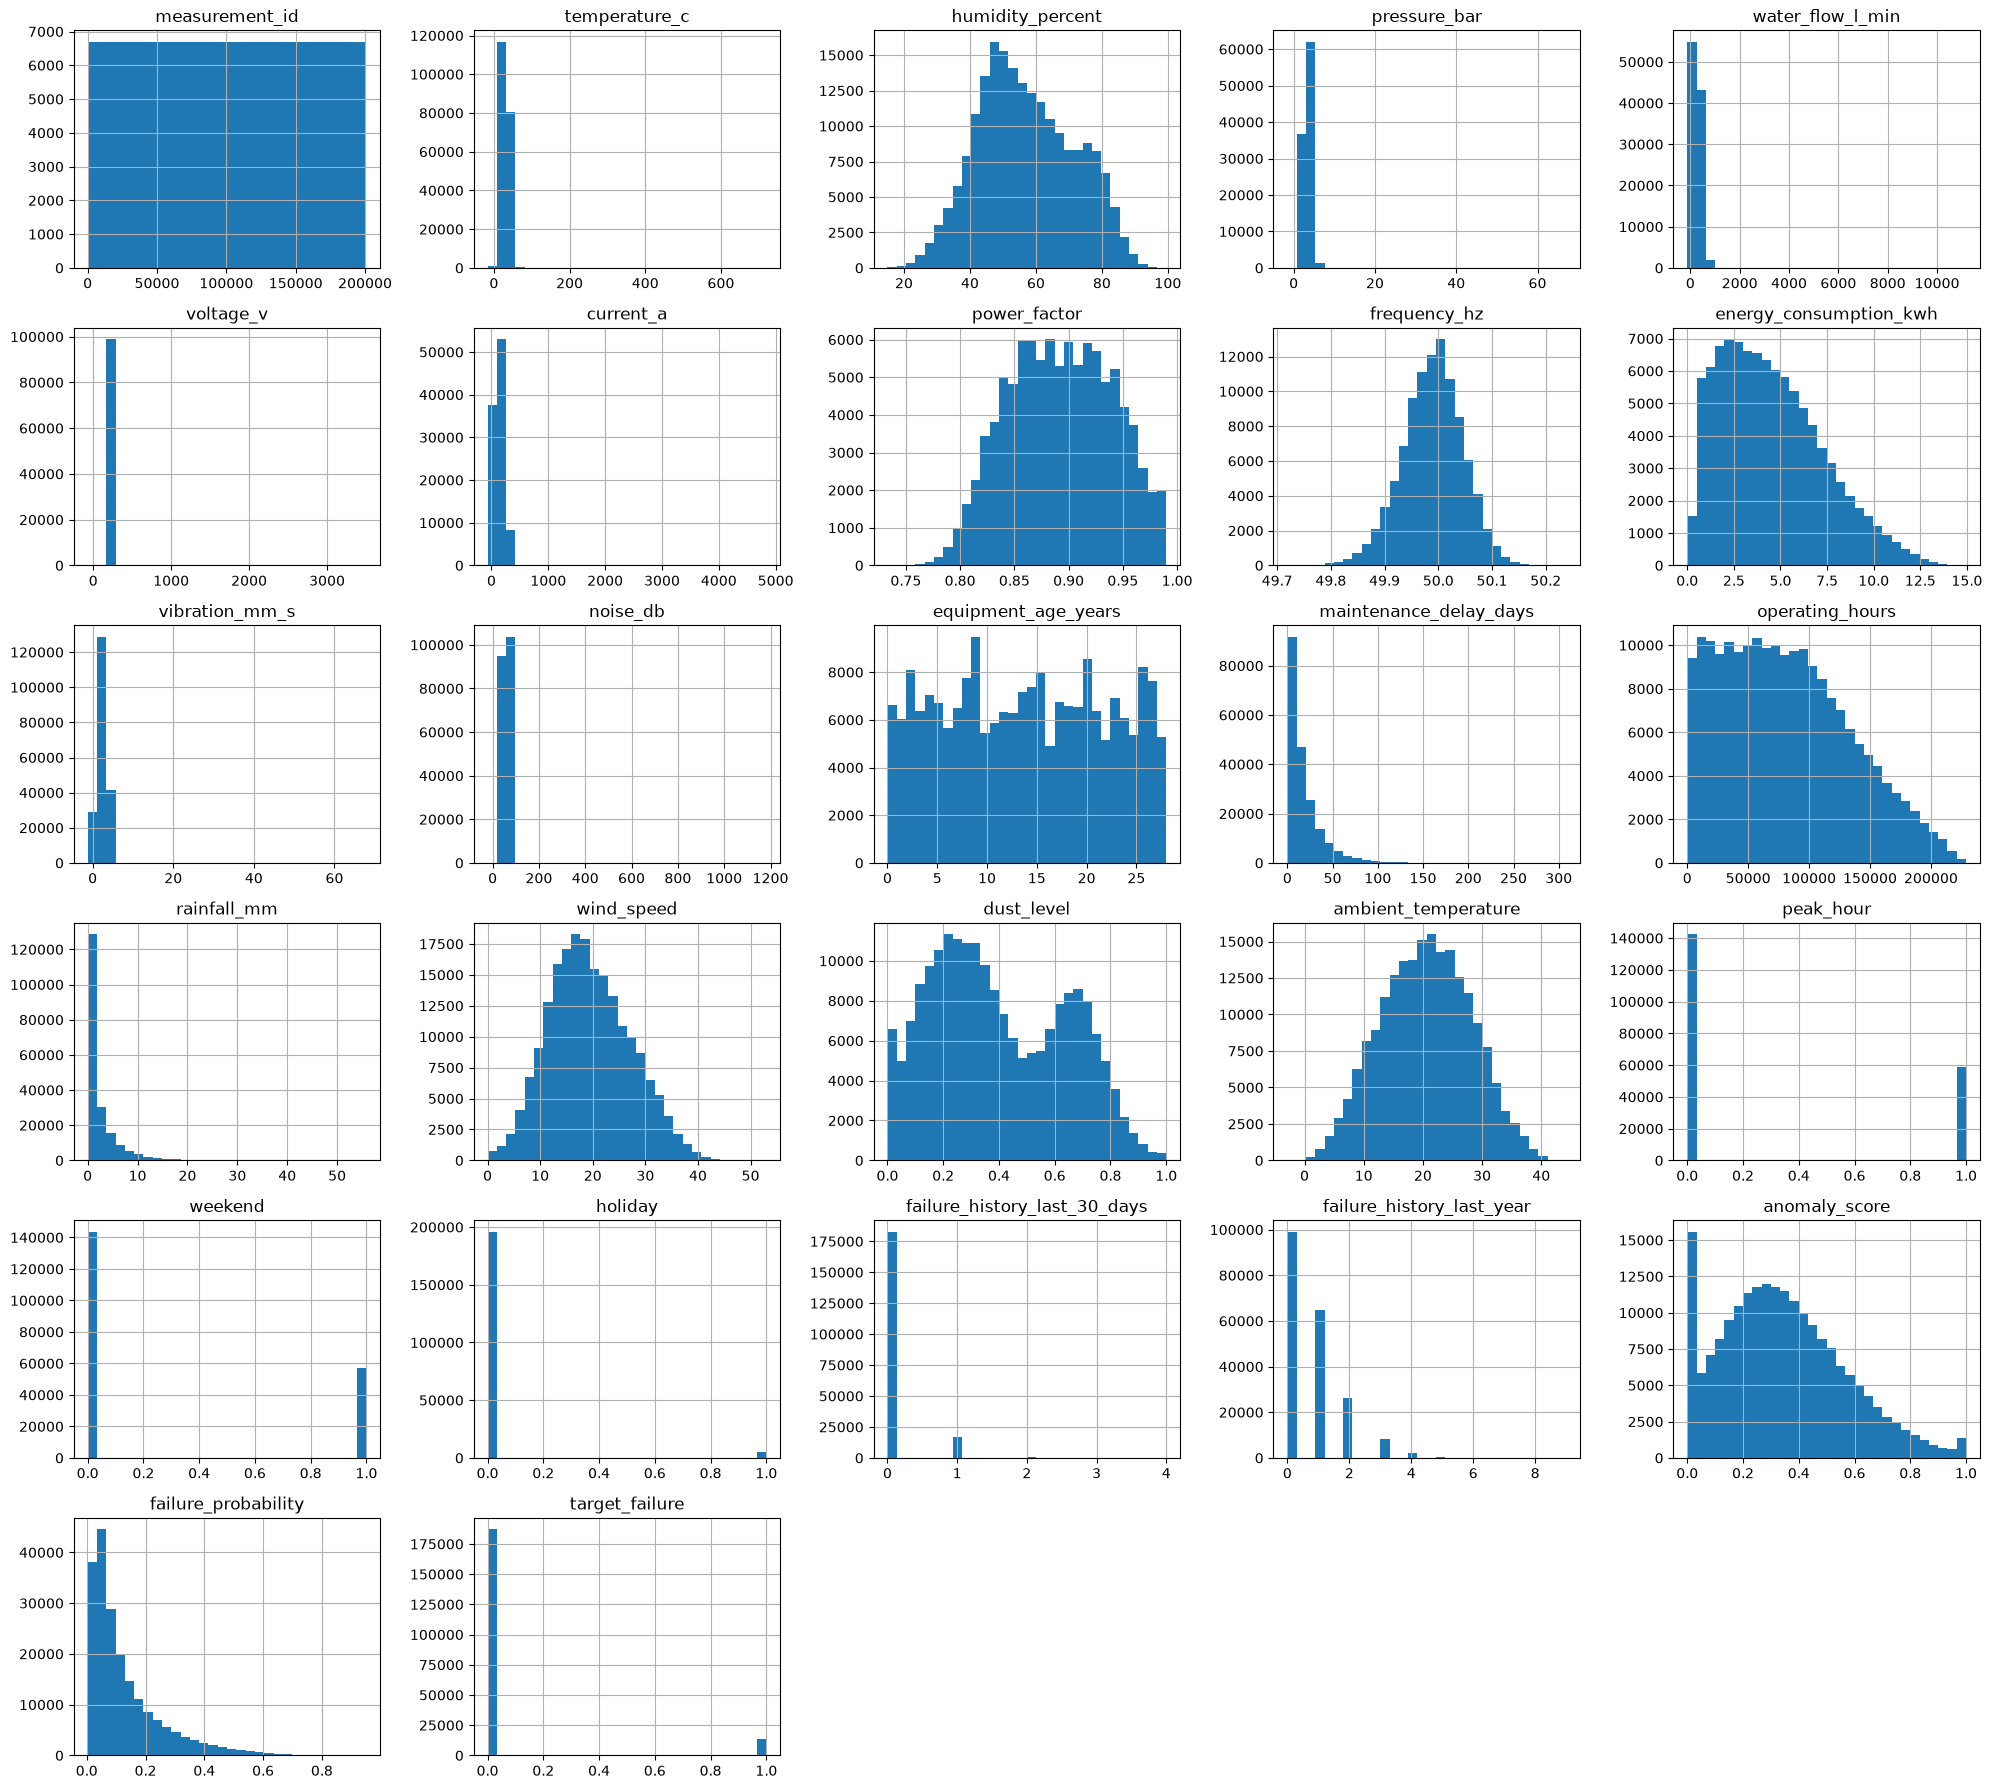

In [26]:
df[numeric_columns].hist(
    figsize=(20, 18),
    bins=30
)

plt.tight_layout()
plt.show()

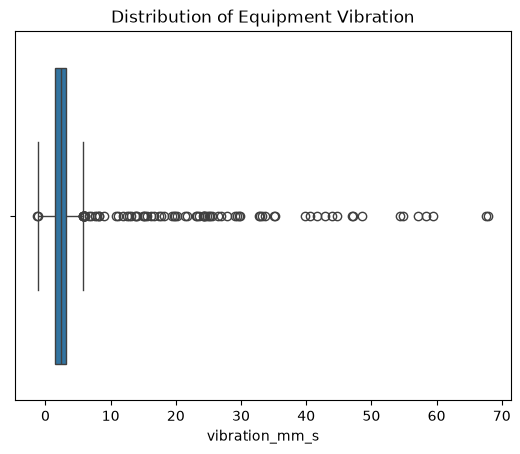

In [27]:
sns.boxplot(
    x=df["vibration_mm_s"]
)

plt.title("Distribution of Equipment Vibration")
plt.show()

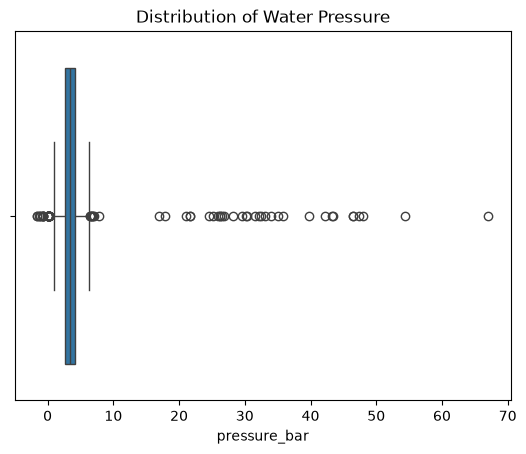

In [28]:
sns.boxplot(
    x=df["pressure_bar"]
)

plt.title("Distribution of Water Pressure")
plt.show()

In [30]:
[col for col in df.columns if "voltage" in col.lower()]

['voltage_v']

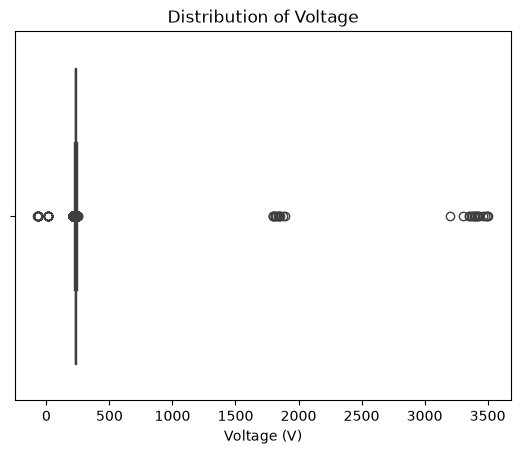

In [31]:
sns.boxplot(
    x=df["voltage_v"]
)

plt.title("Distribution of Voltage")
plt.xlabel("Voltage (V)")
plt.show()

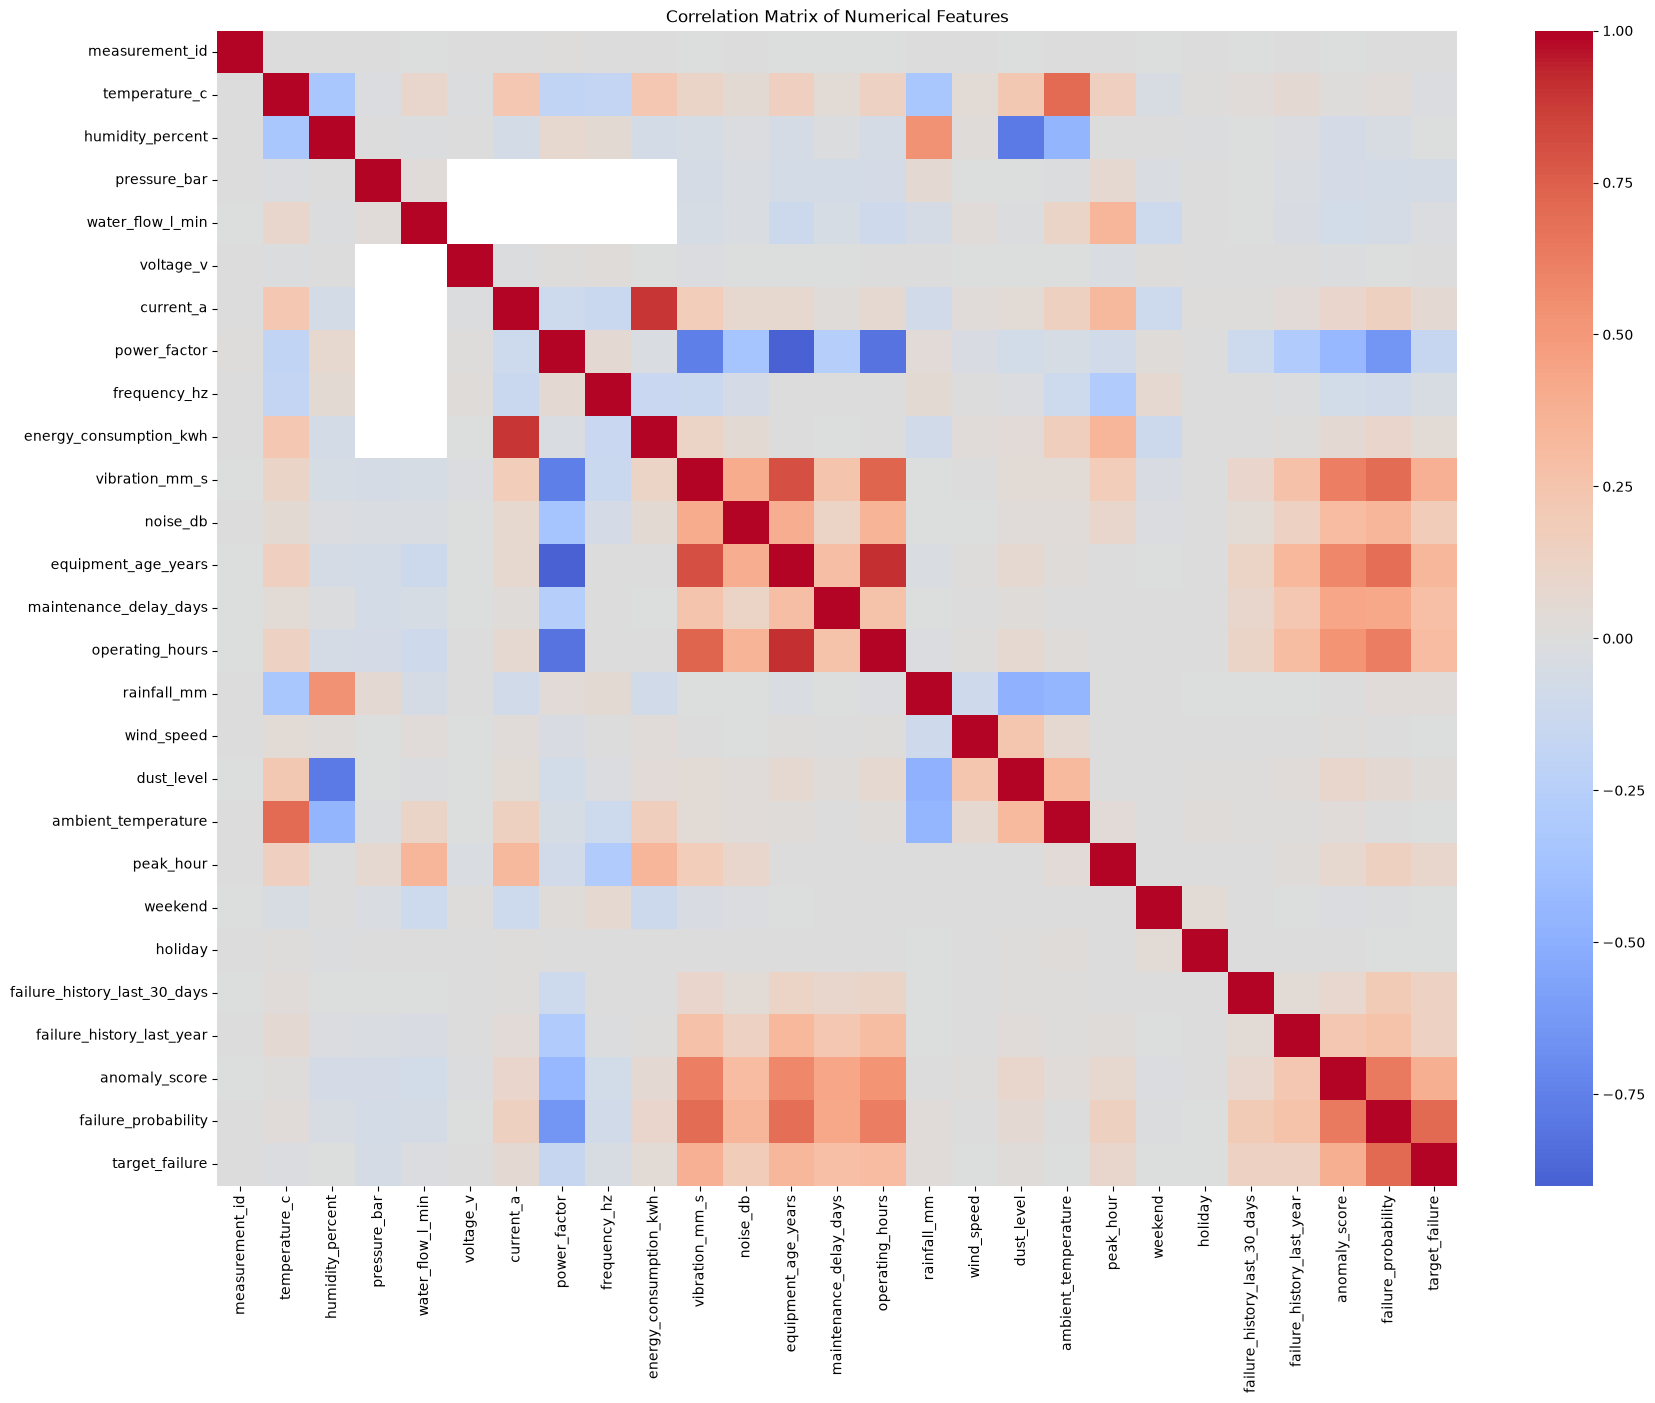

In [32]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(20, 15))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [33]:
failure_correlation = (
    correlation_matrix["target_failure"]
    .sort_values(ascending=False)
)

failure_correlation

target_failure                  1.000000
failure_probability             0.712093
anomaly_score                   0.390766
vibration_mm_s                  0.376751
equipment_age_years             0.333124
operating_hours                 0.302425
maintenance_delay_days          0.282462
noise_db                        0.183685
failure_history_last_year       0.140383
failure_history_last_30_days    0.133102
peak_hour                       0.088144
current_a                       0.060976
energy_consumption_kwh          0.045213
rainfall_mm                     0.031931
dust_level                      0.020035
voltage_v                       0.002912
measurement_id                  0.002024
wind_speed                     -0.003327
ambient_temperature            -0.005641
weekend                        -0.005950
holiday                        -0.005963
humidity_percent               -0.008203
temperature_c                  -0.018615
water_flow_l_min               -0.022876
frequency_hz    

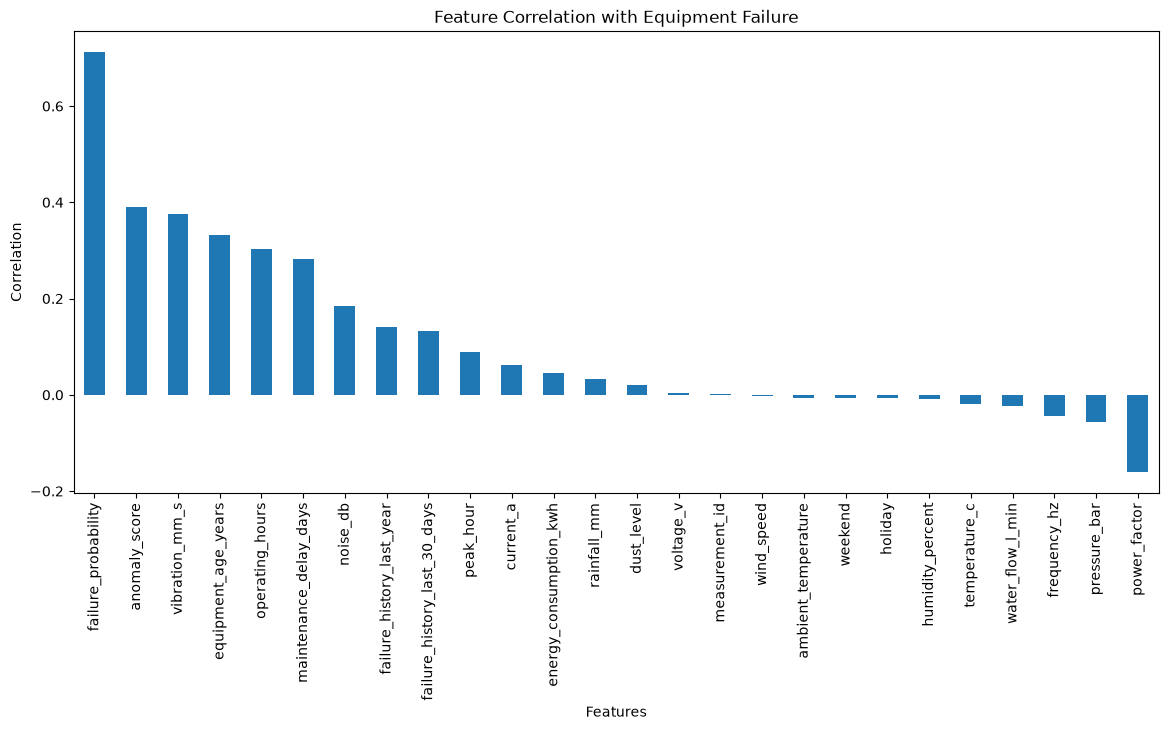

In [34]:
failure_correlation.drop(
    "target_failure"
).plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Feature Correlation with Equipment Failure")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.show()

In [35]:
failure_comparison = df.groupby(
    "target_failure"
)[[
    "vibration_mm_s",
    "equipment_age_years",
    "maintenance_delay_days",
    "operating_hours",
    "anomaly_score",
    "failure_probability"
]].mean()

failure_comparison

,vibration_mm_s,equipment_age_years,maintenance_delay_days,operating_hours,anomaly_score,failure_probability
target_failure,,,,,,
0,2.24697,13.157446,16.371710,77018.980192,0.319039,0.105849
1,4.14424,23.797944,38.367611,139305.515270,0.659274,0.462102
